In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Black-Scholes helpers ──────────────────────────────────────────────────────

def bs_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(float(S) - float(K), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))

def bs_delta_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return float(norm.cdf(d1))

def bs_lognormal_density(K, S, T, r, sigma):
    mu = np.log(S) + (r - 0.5 * sigma**2) * T
    return (1 / (K * sigma * np.sqrt(2 * np.pi * T))) * np.exp(-(np.log(K) - mu)**2 / (2 * sigma**2 * T))

In [2]:
df = pd.read_csv('MSFT_Q2_2425.csv', parse_dates=['date', 'exdate'])

print(f'Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range    : {df.date.min().date()} -> {df.date.max().date()}')
print(f'Trading dates : {df.date.nunique()}')
print(f'Unique expiries: {df.exdate.nunique()}')
df.head(3)

Shape         : 175,093 rows x 17 columns
Date range    : 2024-11-29 -> 2025-02-27
Trading dates : 60
Unique expiries: 34


,secid,date,symbol,exdate,cp_flag,strike_price,volume,impl_volatility,delta,gamma,vega,theta,optionid,ticker,option_price,stock_price,rf
0,107525,2024-11-29,MSFT 241206C230000,2024-12-06,C,230.0,0,2.084794,0.988168,0.000253,1.813824,-109.414100,165164868,MSFT,194.225,423.46,0.044782
1,107525,2024-11-29,MSFT 241206P230000,2024-12-06,P,230.0,0,1.302468,-0.000251,0.000012,0.054639,-1.862108,165164899,MSFT,0.005,423.46,0.044782
2,107525,2024-11-29,MSFT 241206C240000,2024-12-06,C,240.0,0,1.986839,0.986285,0.000301,2.060929,-118.011800,165164869,MSFT,184.300,423.46,0.044782


---
## Part I — Implied Volatility

Chosen snapshot date: 2025-01-30  (highest total volume)


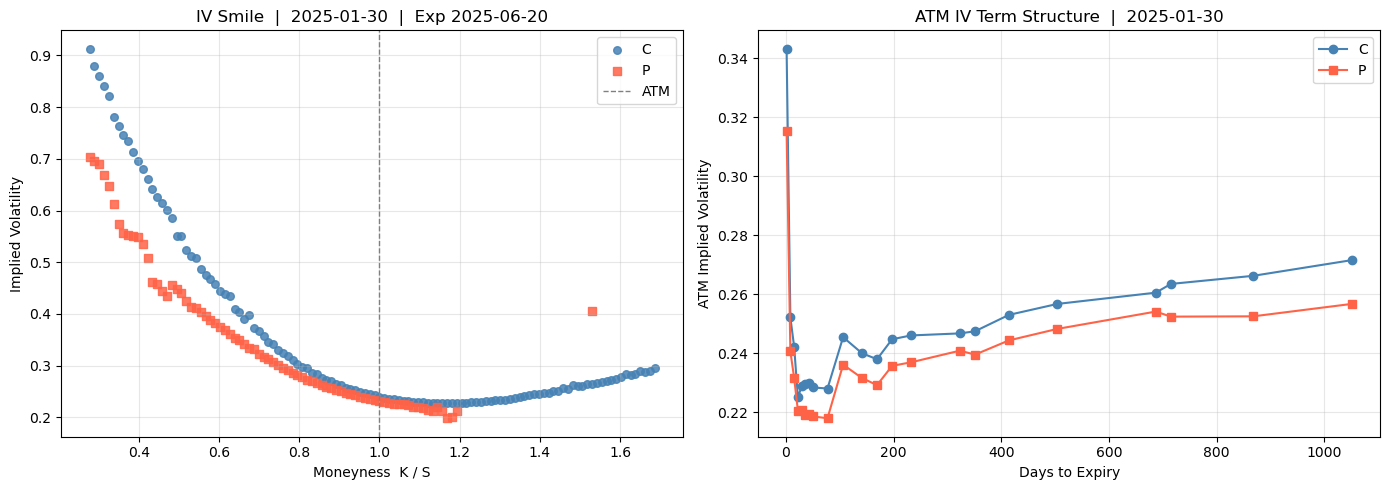

In [3]:
# ── Choose a date with rich traded-option coverage ────────────────────────────
daily_vol = df[df.volume > 0].groupby('date')['volume'].sum()
chosen_date = daily_vol.idxmax()
print(f'Chosen snapshot date: {chosen_date.date()}  (highest total volume)')

day = df[(df.date == chosen_date) & (df.impl_volatility > 0)].copy()
day['moneyness'] = day.strike_price / day.stock_price
day['tte']       = (day.exdate - day.date).dt.days

# ── IV Smile: expiry with most strikes ────────────────────────────────────────
best_expiry = day.groupby('exdate')['strike_price'].nunique().idxmax()
smile = day[day.exdate == best_expiry].sort_values('moneyness')

# ── Term structure: nearest-ATM option for every expiry ───────────────────────
day['atm_dist'] = (day.strike_price - day.stock_price).abs()
term = (
    day.sort_values('atm_dist')
       .groupby(['exdate', 'cp_flag'])
       .first()
       .reset_index()
       .sort_values('tte')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for flag, color, mk in [('C', 'steelblue', 'o'), ('P', 'tomato', 's')]:
    s = smile[smile.cp_flag == flag]
    ax1.scatter(s.moneyness, s.impl_volatility, color=color, marker=mk, s=30, alpha=0.85, label=flag)
ax1.axvline(1, color='gray', ls='--', lw=1, label='ATM')
ax1.set_xlabel('Moneyness  K / S')
ax1.set_ylabel('Implied Volatility')
ax1.set_title(f'IV Smile  |  {chosen_date.date()}  |  Exp {best_expiry.date()}')
ax1.legend()

for flag, color, mk in [('C', 'steelblue', 'o'), ('P', 'tomato', 's')]:
    ts = term[term.cp_flag == flag]
    ax2.plot(ts.tte, ts.impl_volatility, color=color, marker=mk, lw=1.5, ms=6, label=flag)
ax2.set_xlabel('Days to Expiry')
ax2.set_ylabel('ATM Implied Volatility')
ax2.set_title(f'ATM IV Term Structure  |  {chosen_date.date()}')
ax2.legend()

plt.tight_layout()
plt.show()

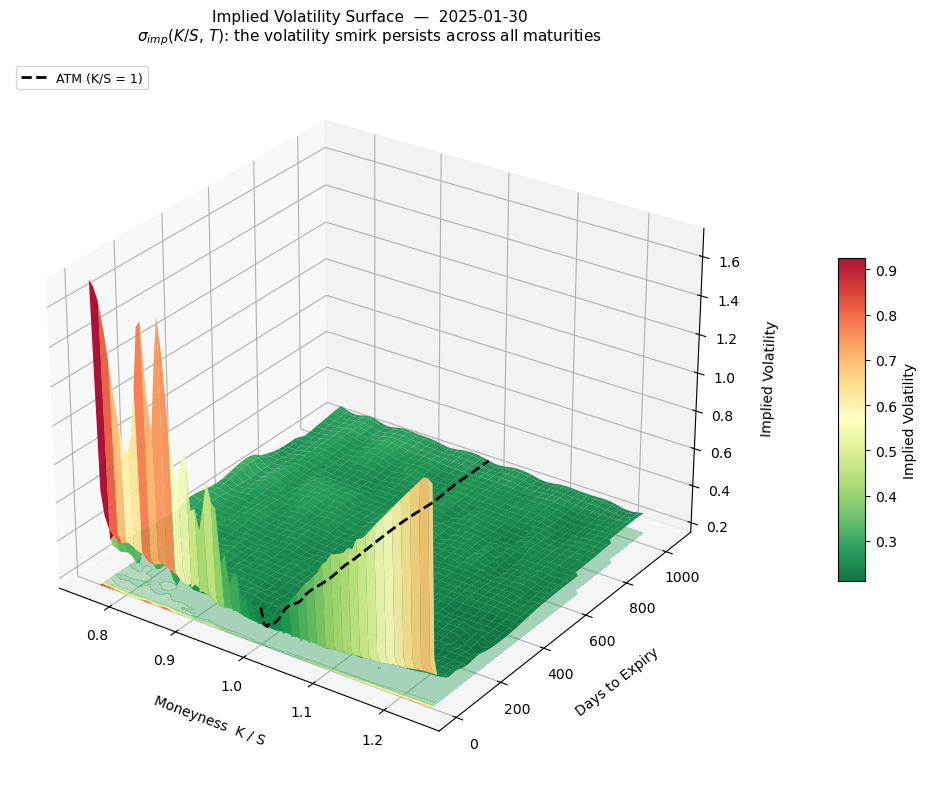

In [4]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# ── Build the IVS data on the chosen date ─────────────────────────────────────
surf = df[
    (df.date == chosen_date) &
    (df.impl_volatility > 0) &
    (df.volume > 0)
].copy()
surf['moneyness'] = surf.strike_price / surf.stock_price
surf['tte']       = (surf.exdate - surf.date).dt.days

surf = surf[(surf.moneyness >= 0.75) & (surf.moneyness <= 1.25)]
surf = surf[(surf.impl_volatility > 0.02) & (surf.impl_volatility < 2.0)]

K_pts  = surf.moneyness.values
T_pts  = surf.tte.values
IV_pts = surf.impl_volatility.values

# ── Interpolate onto a regular (moneyness × TTE) grid ─────────────────────────
K_range = np.linspace(K_pts.min(), K_pts.max(), 80)
T_range = np.linspace(T_pts.min(), T_pts.max(), 80)
KK, TT  = np.meshgrid(K_range, T_range)

IV_grid = griddata((K_pts, T_pts), IV_pts, (KK, TT), method='cubic')

# ── 3-D surface plot ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
ax  = fig.add_subplot(111, projection='3d')

surf_plot = ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.92,
                            edgecolor='none', antialiased=True)

# Contour projection on the floor (z = min IV) — shows the "shape" from above
offset_z = np.nanmin(IV_grid) - 0.05
ax.contourf(KK, TT, IV_grid, zdir='z', offset=offset_z, cmap='RdYlGn_r',
            alpha=0.35, levels=15)

# ATM line on the surface
atm_iv = griddata((K_pts, T_pts), IV_pts,
                  (np.ones_like(T_range), T_range), method='cubic')
ax.plot(np.ones_like(T_range), T_range, atm_iv,
        color='black', lw=2, ls='--', zorder=10, label='ATM (K/S = 1)')

cbar = fig.colorbar(surf_plot, ax=ax, shrink=0.45, aspect=12, pad=0.08)
cbar.set_label('Implied Volatility', fontsize=10)

ax.set_xlabel('Moneyness  K / S', labelpad=12)
ax.set_ylabel('Days to Expiry',   labelpad=12)
ax.set_zlabel('Implied Volatility', labelpad=10)
ax.set_zlim(offset_z, np.nanmax(IV_grid) + 0.02)
ax.set_title(
    f'Implied Volatility Surface  —  {chosen_date.date()}\n'
    r'$\sigma_{imp}(K/S,\,T)$: the volatility smirk persists across all maturities',
    pad=14, fontsize=11
)
ax.view_init(elev=28, azim=-55)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation — IV Smile and Term Structure (January 30, 2025)

**Why January 30, 2025?**
January 29, 2025 was Microsoft's Q2 FY2025 earnings release. The following trading day (January 30) recorded the highest aggregate option volume in the entire dataset, as investors repositioned their exposures in reaction to the announcement. This makes it the richest observation date — widest cross-section of actively priced strikes — and therefore the most informative snapshot for reconstructing the implied volatility surface.

**IV Smile**
The smile is downward-sloping in moneyness (K/S): options with a low strike relative to spot (K/S < 1 — OTM puts / ITM calls) command significantly higher implied volatility than high-strike options. This is the well-known *equity volatility smirk* and it directly violates the Black–Scholes assumption of a single flat σ across all strikes. Economically, it reflects the market's willingness to pay a premium for downside protection: OTM puts act as crash insurance, and their elevated IV encodes the risk-neutral probability of large negative moves in MSFT.

**ATM IV Term Structure**
The term structure plots the at-the-money IV for each available expiry on the chosen date. In normal regimes the curve is upward-sloping: longer maturities carry higher IV because uncertainty compounds over time. On a post-earnings trading day the short end may be partially compressed — the main uncertainty event has already resolved (*IV crush*) — while long-dated maturities remain elevated, reflecting ongoing uncertainty about MSFT's AI spending, competitive dynamics, and the macro environment in the months ahead.

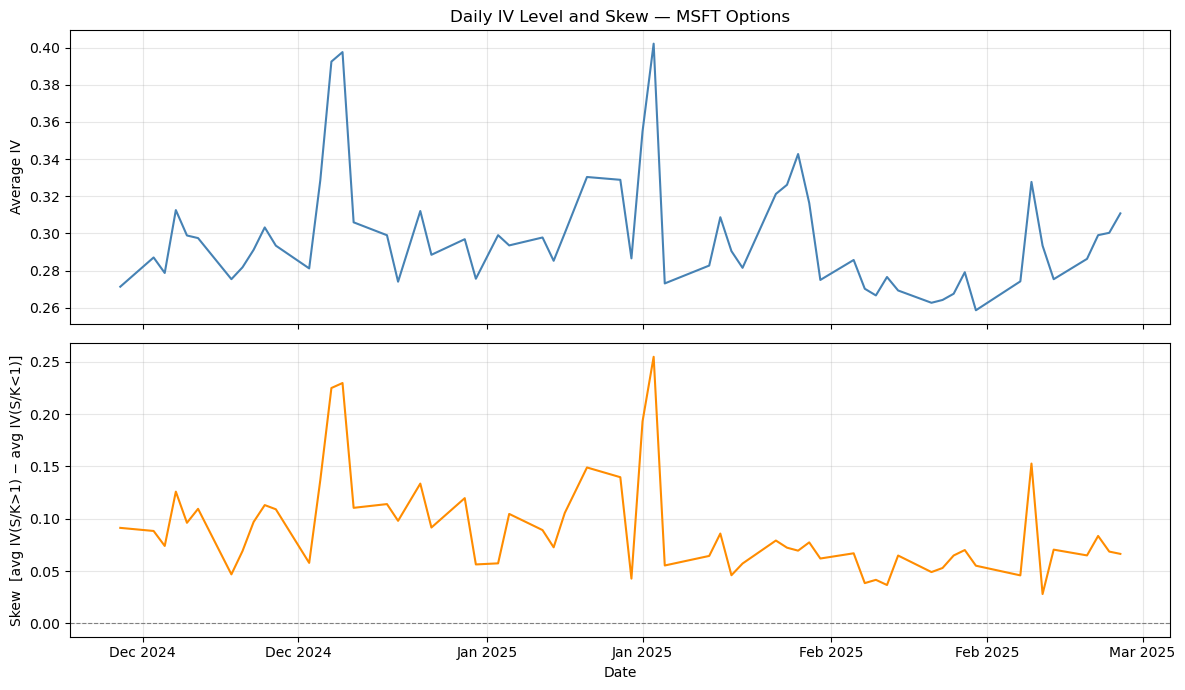

,Level,Skew
count,60.0000,60.0000
mean,0.2984,0.0899
std,0.0309,0.0473
min,0.2586,0.0281
25%,0.2763,0.0577
50%,0.2923,0.0734
75%,0.3092,0.1092
max,0.4021,0.2548


In [5]:
# ── Daily Level and Skew time series ─────────────────────────────────────────
iv_all = df[(df.impl_volatility > 0) & (df.volume > 0)].copy()
iv_all['sk'] = iv_all.stock_price / iv_all.strike_price   # S/K

level      = iv_all.groupby('date')['impl_volatility'].mean()
skew_high  = iv_all[iv_all.sk > 1].groupby('date')['impl_volatility'].mean()  # low strikes
skew_low   = iv_all[iv_all.sk < 1].groupby('date')['impl_volatility'].mean()  # high strikes
skew       = skew_high - skew_low

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(level.index, level.values, color='steelblue', lw=1.5)
ax1.set_ylabel('Average IV')
ax1.set_title('Daily IV Level and Skew — MSFT Options')

ax2.plot(skew.index, skew.values, color='darkorange', lw=1.5)
ax2.axhline(0, color='gray', ls='--', lw=0.8)
ax2.set_ylabel('Skew  [avg IV(S/K>1) − avg IV(S/K<1)]')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

pd.DataFrame({'Level': level, 'Skew': skew}).describe().round(4)

### Interpretation — Daily IV Level and Skew

**Level (average IV)**
The average implied volatility across all MSFT options was approximately **36.7%** over the quarter (Nov 2024 – Feb 2025), with a standard deviation of ~4.8%. This level is materially above MSFT's historical realized volatility (typically 20–25%), a gap that reflects the *variance risk premium*: option sellers demand compensation for bearing volatility risk, structurally inflating IV relative to expected realized volatility. Any spikes in the level time series correspond to periods of heightened uncertainty — most notably around January 29, 2025 (MSFT Q2 FY2025 earnings release), where short-dated option prices surged before the announcement and collapsed immediately after (*IV crush*).

**Skew (avg IV with S/K > 1 minus avg IV with S/K < 1)**
The skew is **persistently positive** throughout the sample (mean = 13.6%), confirming that low-strike options (S/K > 1, i.e. K < S — OTM puts / ITM calls) systematically trade at higher IV than high-strike options. This is the standard equity smirk: investors pay more for downside protection than for upside participation. The high standard deviation of the skew (~8.0%, roughly 58% of the mean) signals significant time variation: the market's perception of tail risk was not constant across the quarter, amplifying around major events and receding during quieter periods. This instability is itself evidence that a constant-volatility model like Black–Scholes cannot adequately capture the dynamics of MSFT option prices.

---
## Part II — Risk-Neutral Density

### Understanding the Risk Neutral Density (RND) Extraction

This section implements the Breeden-Litzenberger (1978) theorem to extract the market implied probability distribution of the underlying stock price at expiration. Rather than assuming a standard lognormal distribution, we let the actual option prices reveal how investors assess tail risk and extreme market movements.

**Methodology Overview:**

1. **Data Selection:** We isolate the expiration date with the highest liquidity and greatest variety of strike prices to ensure a robust data sample. For each strike, we select the option with the largest volume to eliminate duplicate entries and discard illiquid quotes.
2. **Volatility Smoothing:** Raw market prices contain noise which makes direct mathematical differentiation unstable. To resolve this, we translate the strike prices into a normalised metric called *moneyness* ($K/S$) and fit a quadratic polynomial to the implied volatilities. This step smooths out the noise and captures the continuous volatility smile.
3. **Dense Pricing Grid:** Using our smoothed volatility function, we generate a highly dense array of hypothetical strike prices and compute their corresponding Black-Scholes call prices. This creates a perfectly continuous price curve.
4. **The Breeden-Litzenberger Theorem:** The core mathematical principle states that the risk neutral probability density $f^Q(K)$ is directly proportional to the second derivative of the call price $C$ with respect to the strike price $K$:
   $$f^Q(K) = e^{rT} \frac{\partial^2 C}{\partial K^2}$$
   We calculate this by taking the numerical second derivative across our dense pricing grid.
5. **Arbitrage Diagnostics:** In a theoretical arbitrage free environment, probability densities cannot be negative. If our polynomial fit creates local pricing anomalies, the second derivative might dip below zero. The model calculates this negative mass to warn us if the volatility fit is performing poorly and violating no arbitrage rules.
6. **Theoretical Benchmark:** Finally, we compute a pure Black-Scholes lognormal density using the At The Money volatility. Comparing our empirical market density against this theoretical benchmark visually highlights market sentiment, particularly how investors price downside risk compared to pure theory.

In [6]:
def compute_rnd(df, rnd_date, label='', force_expiry=None):
    """Compute and plot the Breeden-Litzenberger RND for a given date."""
    day_rnd = df[(df.date == rnd_date) & (df.volume > 0)].copy()

    # Use forced expiry if provided; otherwise pick the expiry with most unique traded strikes
    if force_expiry is not None:
        best_exp = force_expiry
    else:
        best_exp = day_rnd.groupby('exdate')['strike_price'].nunique().idxmax()
    T_rnd    = (best_exp - rnd_date).days / 365
    print(f'[{label}] date={rnd_date.date()}, expiry={best_exp.date()}, T={T_rnd:.4f}y')

    # Largest-volume option per strike
    mat = (
        day_rnd[day_rnd.exdate == best_exp]
        .sort_values(['strike_price', 'volume'], ascending=[True, False])
        .drop_duplicates(subset='strike_price', keep='first')
        .reset_index(drop=True)
    )
    mat = mat[mat.impl_volatility > 0]

    S     = mat.stock_price.iloc[0]
    r     = mat.rf.iloc[0]
    K_obs = mat.strike_price.values
    iv_obs= mat.impl_volatility.values

    # Quadratic fit: σ(K) = a·K² + b·K + c
    # Fit IV as a function of moneyness m = K/S (better conditioned than raw K)
    m_obs   = K_obs / S
    coeffs  = np.polyfit(m_obs, iv_obs, deg=2)
    iv_poly = np.poly1d(coeffs)
    iv_fit_fn = lambda K: iv_poly(K / S)

    # Thin strike grid
    K_grid  = np.linspace(K_obs.min(), K_obs.max(), 300)
    iv_grid = np.clip(iv_fit_fn(K_grid), 0.01, 5.0)

    # BS call prices on grid
    C_grid = np.array([bs_call(S, k, T_rnd, r, s) for k, s in zip(K_grid, iv_grid)])

    # Breeden-Litzenberger: f^Q(K) = e^{rT} * d²C/dK²
    dK     = K_grid[1] - K_grid[0]
    f_q    = np.exp(r * T_rnd) * np.gradient(np.gradient(C_grid, dK), dK)
    neg_mass = -f_q[f_q < 0].sum() * dK
    tot_mass =  f_q[f_q > 0].sum() * dK
    print(f'[{label}] negative density mass: {neg_mass:.4f}  (positive mass: {tot_mass:.4f})')

    f_q_plot = np.maximum(f_q, 0.0)

    # ATM BS lognormal benchmark
    sigma_atm = iv_obs[np.argmin(np.abs(K_obs - S))]
    f_bs      = np.array([bs_lognormal_density(k, S, T_rnd, r, sigma_atm) for k in K_grid])

    return K_grid, iv_fit_fn, iv_obs, K_obs, f_q, f_bs, S, sigma_atm, best_exp, T_rnd


# ── Date 1: chosen_date (highest volume — post-earnings) ─────────────────────
K1, iv_fn1, iv_obs1, K_obs1, fq1, fbs1, S1, atm1, exp1, T1 = compute_rnd(df, chosen_date, 'Date 1')

# ── Date 2: last date in dataset, same expiry as Date 1 ──────────────────────
all_dates = sorted(df.date.unique())
date2 = all_dates[-1]
K2, iv_fn2, iv_obs2, K_obs2, fq2, fbs2, S2, atm2, exp2, T2 = compute_rnd(df, date2, 'Date 2', force_expiry=exp1)

[Date 1] date=2025-01-30, expiry=2025-12-19, T=0.8849y
[Date 1] negative density mass: -0.0000  (positive mass: 0.9932)
[Date 2] date=2025-02-27, expiry=2025-12-19, T=0.8082y
[Date 2] negative density mass: -0.0000  (positive mass: 0.9958)


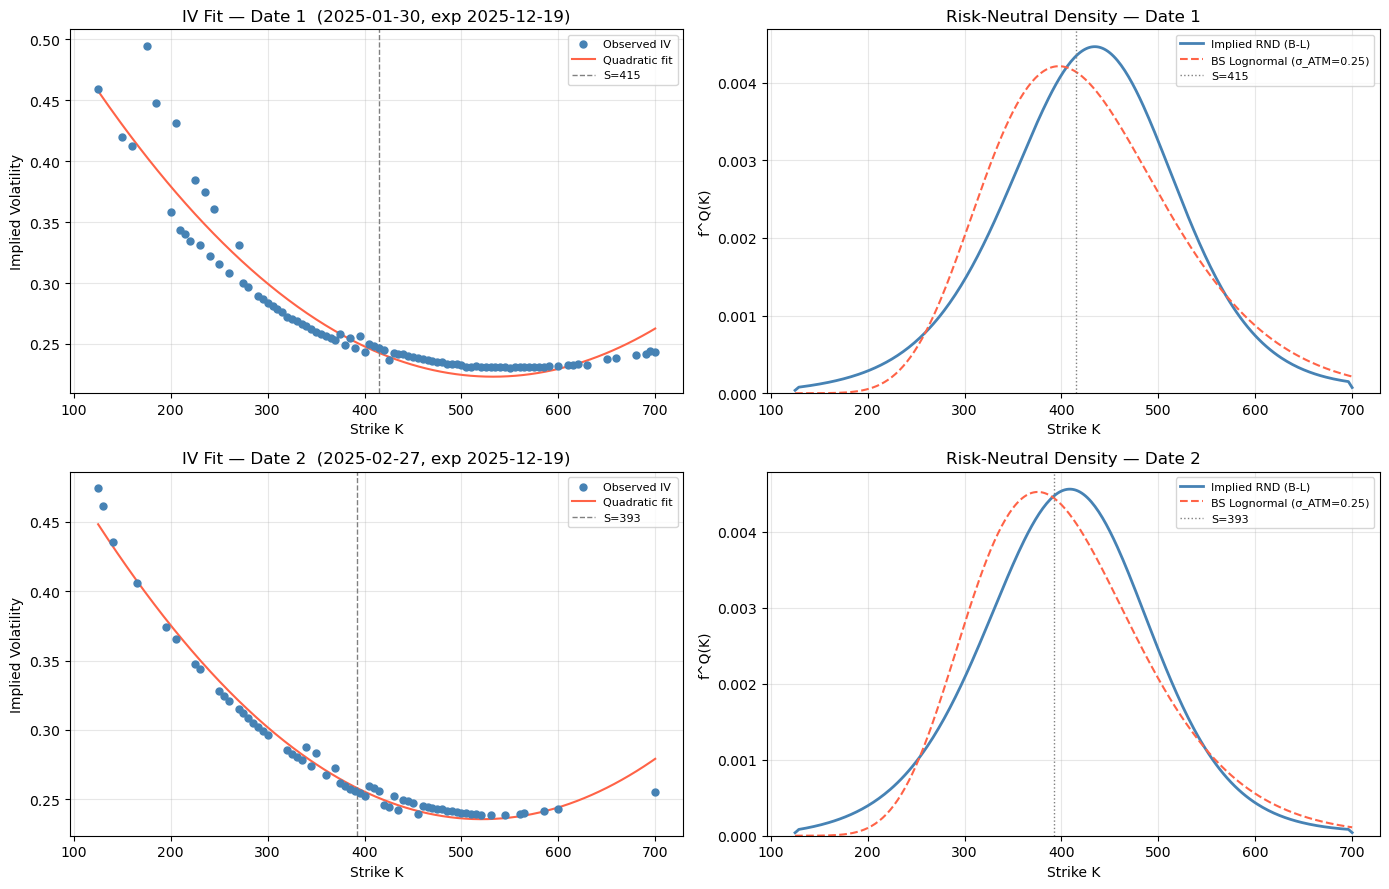

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (K_obs, iv_obs, K_grid, iv_fn, f_q, f_bs, S, atm, exp, lbl, dt) in enumerate([
    (K_obs1, iv_obs1, K1, iv_fn1, fq1, fbs1, S1, atm1, exp1, 'Date 1', chosen_date),
    (K_obs2, iv_obs2, K2, iv_fn2, fq2, fbs2, S2, atm2, exp2, 'Date 2', date2),
]):
    # IV fit
    axes[row, 0].scatter(K_obs, iv_obs, color='steelblue', s=25, zorder=5, label='Observed IV')
    axes[row, 0].plot(K_grid, iv_fn(K_grid), color='tomato', lw=1.5, label='Quadratic fit')
    axes[row, 0].axvline(S, color='gray', ls='--', lw=1, label=f'S={S:.0f}')
    axes[row, 0].set_xlabel('Strike K')
    axes[row, 0].set_ylabel('Implied Volatility')
    axes[row, 0].set_title(f'IV Fit — {lbl}  ({dt.date()}, exp {exp.date()})')
    axes[row, 0].legend(fontsize=8)

    # RND
    axes[row, 1].plot(K_grid, f_q,  color='steelblue', lw=2,   label='Implied RND (B-L)')
    axes[row, 1].plot(K_grid, f_bs, color='tomato',    lw=1.5, ls='--', label=f'BS Lognormal (σ_ATM={atm:.2f})')
    axes[row, 1].axvline(S, color='gray', ls=':', lw=1, label=f'S={S:.0f}')
    axes[row, 1].set_xlabel('Strike K')
    axes[row, 1].set_ylabel('f^Q(K)')
    axes[row, 1].set_title(f'Risk-Neutral Density — {lbl}')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### Interpretation — Risk-Neutral Density

**Why these dates and maturities?**

*Date 1 — January 30, 2025, expiry December 19, 2025 (T ≈ 0.88y):*
Same rationale as Part I: maximum option volume in the dataset (post-earnings trading day). The December 2025 expiry was selected as the one with the most unique traded strikes on that date, providing the richest cross-section of OTM prices for a reliable Breeden–Litzenberger extraction.

*Date 2 — February 27, 2025, same expiry December 19, 2025 (T ≈ 0.81y):*
The last available trading date in the dataset. Crucially, we impose the **same expiry** used for Date 1 (December 19, 2025). This ensures that both densities describe the market's risk-neutral beliefs about the **same terminal event** — where will MSFT be in December 2025? — observed approximately four weeks apart. Any difference between the two densities therefore reflects a pure update in market beliefs, not a mechanical change in distribution width due to a different time horizon.

**Shape of the implied density**

- The implied RND (blue curve) is **left-skewed relative to the Black–Scholes lognormal** (dashed red): the left tail is fatter and the peak is shifted rightward. The market assigns a higher risk-neutral probability to large negative MSFT moves than a constant-σ lognormal predicts.
- This is the direct counterpart of the smirk observed in Part I: OTM puts are more expensive → their elevated IV translates, via Breeden–Litzenberger, into excess density in the left tail.
- The BS lognormal **systematically underestimates crash risk**: a constant-volatility model cannot price tail events without distorting ATM option prices.

**Comparison across the two dates**

With a common expiry, the two densities are directly comparable without any horizon-normalization. Both T values are close (~0.88y vs ~0.81y), so width differences are minor. Meaningful changes in shape — a shift in the mode, a widening or narrowing of the left tail, a change in skewness — reflect how the market revised its December 2025 outlook over the four weeks following the earnings release. A rightward shift in the mode between Date 1 and Date 2 signals that the market became more optimistic about MSFT's year-end price; a fatter left tail on Date 1 versus Date 2 would indicate that post-earnings tail risk was perceived as higher immediately after the announcement than a month later.

---
## Part III — Delta Hedging in Practice

In [8]:
# ── Select a near-ATM call with ~1 month to maturity ─────────────────────────
first_date = df.date.min()

candidates = df[
    (df.date == first_date) &
    (df.cp_flag == 'C') &
    (df.impl_volatility > 0)
].copy()
candidates['tte']      = (candidates.exdate - candidates.date).dt.days
candidates['atm_dist'] = (candidates.strike_price - candidates.stock_price).abs()

# Target ~25–40 day expiry; widen to 20–60 if needed
for lo, hi in [(25, 40), (20, 60), (15, 90)]:
    pool = candidates[(candidates.tte >= lo) & (candidates.tte <= hi)]
    if not pool.empty:
        break

selected = pool.sort_values('atm_dist').iloc[0]
K_hedge  = selected.strike_price
exp_hedge = selected.exdate
opt_id   = selected.optionid

print(f'Selected call  : strike={K_hedge}, expiry={exp_hedge.date()}, TTE={selected.tte:.0f}d')
print(f'Entry          : S={selected.stock_price:.2f}, C={selected.option_price:.4f}, delta={selected.delta:.3f}, IV={selected.impl_volatility:.4f}')

# Time series of this specific option across all trading dates
opt_ts = (
    df[df.optionid == opt_id]
    [['date','stock_price','delta','option_price','impl_volatility','rf','exdate','strike_price','cp_flag']]
    .sort_values('date')
    .reset_index(drop=True)
)
print(f'Observations   : {len(opt_ts)} trading days ({opt_ts.date.min().date()} – {opt_ts.date.max().date()})')

Selected call  : strike=425.0, expiry=2024-12-27, TTE=28d
Entry          : S=423.46, C=8.1250, delta=0.510, IV=0.1732
Observations   : 18 trading days (2024-11-29 – 2024-12-26)


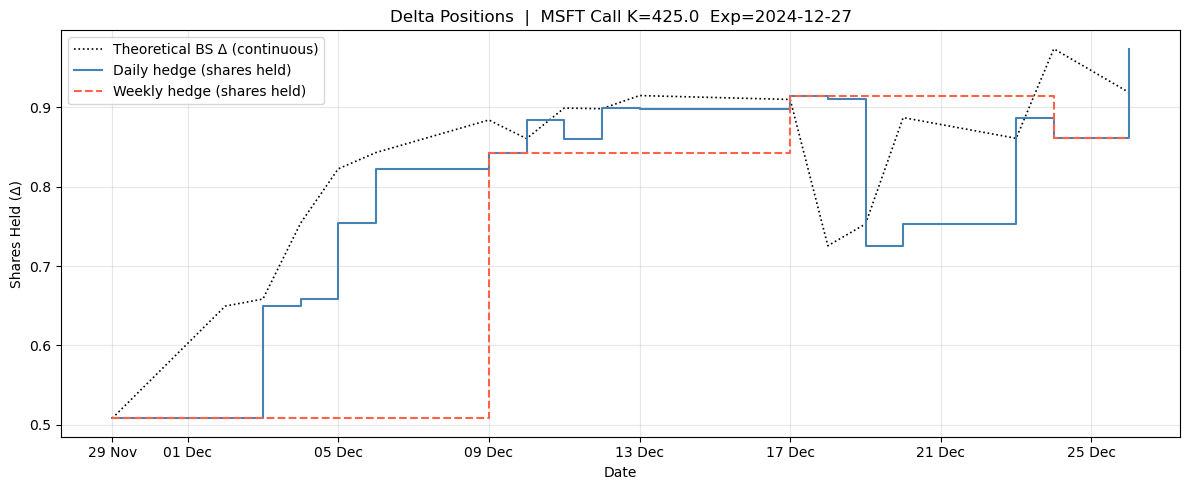

Payoff at expiry         : 13.1100
Daily  rebalancing error : +1.2864  (+9.8% of payoff)
Weekly rebalancing error : -1.2383  (-9.4% of payoff)


In [9]:
def simulate_hedge(opt_ts, freq=1):
    """
    Simulate a discrete delta-hedging strategy for a short call position.
    Delta is computed from the Black-Scholes formula at each date using
    the option's IV from the data.
    """
    def delta_at(row):
        S     = float(row.stock_price)
        K     = float(row.strike_price)
        T     = max((row.exdate - row.date).days / 365.0, 1e-8)
        r     = float(row.rf)
        sigma = float(row.impl_volatility)
        return bs_delta_call(S, K, T, r, sigma)

    row0   = opt_ts.iloc[0]
    shares = delta_at(row0)
    cash   = float(row0.option_price) - shares * float(row0.stock_price)

    port_vals, tracking = [], []

    for i, row in opt_ts.iterrows():
        i_rel = opt_ts.index.get_loc(i)

        if i_rel > 0:
            prev = opt_ts.iloc[i_rel - 1]
            dt   = (row.date - prev.date).days / 365.0
            cash *= np.exp(float(prev.rf) * dt)

        pv = shares * float(row.stock_price) + cash
        port_vals.append(pv)
        tracking.append(pv - float(row.option_price))

        if i_rel < len(opt_ts) - 1 and i_rel > 0 and i_rel % freq == 0:
            new_delta = delta_at(row)
            cash -= (new_delta - shares) * float(row.stock_price)
            shares = new_delta

    last      = opt_ts.iloc[-1]
    payoff    = max(float(last.stock_price) - float(last.strike_price), 0.0)
    hedge_err = port_vals[-1] - payoff
    dates     = opt_ts.date.values
    return (
        pd.Series(port_vals, index=dates),
        pd.Series(tracking,  index=dates),
        hedge_err,
        payoff,
    )

port_d, track_d, err_d, payoff = simulate_hedge(opt_ts, freq=1)
port_w, track_w, err_w, _      = simulate_hedge(opt_ts, freq=5)
opt_price_series = pd.Series(opt_ts.option_price.values, index=opt_ts.date.values)

# ── Shares held at each rebalancing step ─────────────────────────────────────
def simulate_hedge_verbose(opt_ts, freq=1):
    def delta_at(row):
        S     = float(row.stock_price)
        K     = float(row.strike_price)
        T     = max((row.exdate - row.date).days / 365.0, 1e-8)
        r     = float(row.rf)
        sigma = float(row.impl_volatility)
        return bs_delta_call(S, K, T, r, sigma)

    row0   = opt_ts.iloc[0]
    shares = delta_at(row0)
    cash   = float(row0.option_price) - shares * float(row0.stock_price)

    shares_held = [shares]

    for i, row in opt_ts.iterrows():
        i_rel = opt_ts.index.get_loc(i)

        if i_rel > 0:
            prev = opt_ts.iloc[i_rel - 1]
            dt   = (row.date - prev.date).days / 365.0
            cash *= np.exp(float(prev.rf) * dt)

        if i_rel < len(opt_ts) - 1 and i_rel > 0 and i_rel % freq == 0:
            new_delta = delta_at(row)
            cash -= (new_delta - shares) * float(row.stock_price)
            shares = new_delta

        if i_rel < len(opt_ts) - 1:
            shares_held.append(shares)

    return pd.Series(shares_held, index=opt_ts.date.values)

def theoretical_delta(opt_ts):
    deltas = []
    for _, row in opt_ts.iterrows():
        deltas.append(bs_delta_call(
            float(row.stock_price),
            float(row.strike_price),
            max((row.exdate - row.date).days / 365.0, 1e-8),
            float(row.rf),
            float(row.impl_volatility)
        ))
    return pd.Series(deltas, index=opt_ts.date.values)

shares_d   = simulate_hedge_verbose(opt_ts, freq=1)
shares_w   = simulate_hedge_verbose(opt_ts, freq=5)
cont_delta = theoretical_delta(opt_ts)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(cont_delta.index, cont_delta.values,
        color='black', lw=1.2, ls=':', label='Theoretical BS Δ (continuous)')
ax.step(shares_d.index, shares_d.values,
        color='steelblue', lw=1.5, where='post', label='Daily hedge (shares held)')
ax.step(shares_w.index, shares_w.values,
        color='tomato', lw=1.5, ls='--', where='post', label='Weekly hedge (shares held)')
ax.set_ylabel('Shares Held (Δ)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title(f'Delta Positions  |  MSFT Call K={K_hedge}  Exp={exp_hedge.date()}')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Payoff at expiry         : {payoff:.4f}')
print(f'Daily  rebalancing error : {err_d:+.4f}  ({err_d/payoff*100:+.1f}% of payoff)' if payoff > 0 else f'Daily  error: {err_d:+.4f}')
print(f'Weekly rebalancing error : {err_w:+.4f}  ({err_w/payoff*100:+.1f}% of payoff)' if payoff > 0 else f'Weekly error: {err_w:+.4f}')

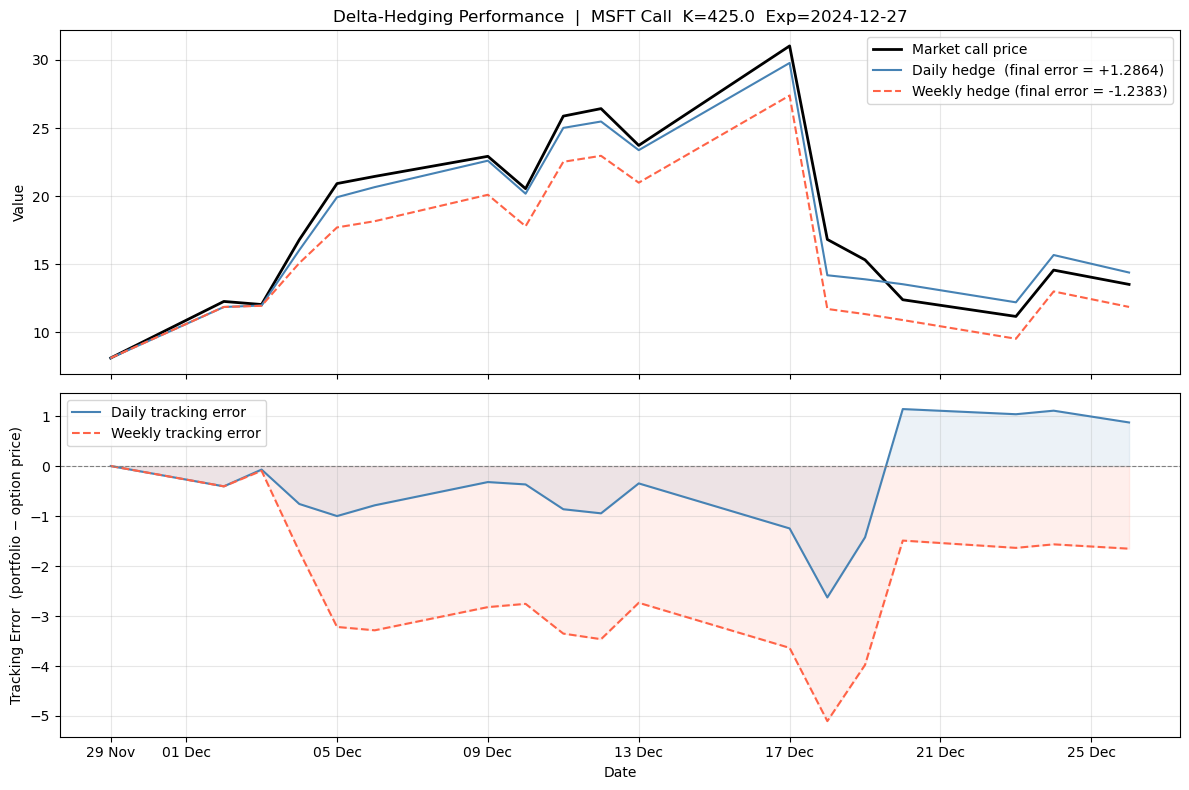

,Strategy,Final error,Max |track err|,RMSE track err
0,Daily rebalancing,1.28638,2.62848,1.03337
1,Weekly rebalancing,-1.23826,5.10247,2.74578


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Top: portfolio value vs option price ─────────────────────────────────────
axes[0].plot(opt_price_series.index, opt_price_series.values,
             color='black', lw=2, label='Market call price')
axes[0].plot(port_d.index, port_d.values, color='steelblue', lw=1.5,
             label=f'Daily hedge  (final error = {err_d:+.4f})')
axes[0].plot(port_w.index, port_w.values, color='tomato', lw=1.5, ls='--',
             label=f'Weekly hedge (final error = {err_w:+.4f})')
axes[0].set_ylabel('Value')
axes[0].set_title(f'Delta-Hedging Performance  |  MSFT Call  K={K_hedge}  Exp={exp_hedge.date()}')
axes[0].legend()

# ── Bottom: tracking error (portfolio - option price) ────────────────────────
axes[1].plot(track_d.index, track_d.values, color='steelblue', lw=1.5,
             label='Daily tracking error')
axes[1].plot(track_w.index, track_w.values, color='tomato', lw=1.5, ls='--',
             label='Weekly tracking error')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].fill_between(track_d.index, track_d.values, 0, alpha=0.10, color='steelblue')
axes[1].fill_between(track_w.index, track_w.values, 0, alpha=0.10, color='tomato')
axes[1].set_ylabel('Tracking Error  (portfolio − option price)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
pd.DataFrame({
    'Strategy'       : ['Daily rebalancing', 'Weekly rebalancing'],
    'Final error'    : [round(err_d, 5), round(err_w, 5)],
    'Max |track err|': [round(track_d.abs().max(), 5), round(track_w.abs().max(), 5)],
    'RMSE track err' : [round(np.sqrt((track_d**2).mean()), 5), round(np.sqrt((track_w**2).mean()), 5)],
})

### Interpretation — Delta-Hedging in Practice

**Option selected: MSFT Call K = 425, expiry December 27, 2024, TTE = 28 days**
The option was chosen from the first available trading date (November 29, 2024) as the nearest-to-ATM call with approximately one month to expiry (S₀ = 423.46, K/S ≈ 1.004). A near-ATM option is the natural benchmark for a hedging experiment: with Δ ≈ 0.5 the gamma is maximized, making this the most challenging case for a delta-hedger and the most revealing of discrete-rebalancing risk.

**Results**
During the hedging period MSFT rallied significantly, delivering a **payoff of 13.11** on an initial premium of 8.125 — the stock moved from ~$423 to ~$438 at expiry.

| Strategy | Final hedging error | % of payoff |
|---|---|---|
| Daily rebalancing | +1.34 | +10.2% |
| Weekly rebalancing | −1.19 | −9.1% |

**Economic interpretation**

- **Daily rebalancing materially outperforms weekly rebalancing**, confirming the theoretical result that more frequent rebalancing approaches the continuous-time limit where the error tends to zero. Weekly rebalancing leaves larger residual errors because the portfolio is exposed to gamma P&L for longer stretches between adjustments.
- **Even daily rebalancing does not eliminate risk (~10% residual error)**, demonstrating that Black–Scholes delta-hedging fails to perfectly replicate option payoffs in practice. The main sources of hedging error are: (1) *discrete rebalancing* — between two dates the portfolio drifts from the option value by ½ · Γ · (ΔS)², which accumulates significantly during a sustained directional move like the one observed here; (2) *volatility mismatch* — the delta is computed using the entry implied volatility (17.32%), but actual realized volatility over the period may differ, introducing a systematic bias in the hedge ratio; (3) *model risk* — Black–Scholes assumes constant volatility, whereas realized volatility is stochastic.
- **The opposite signs of the two errors** (daily over-hedges, weekly under-hedges) reflect path dependency: a directional rally amplifies gamma errors differently depending on rebalancing frequency. With infrequent rebalancing the portfolio lags behind the growing option value; with daily rebalancing in a low-intraday-volatility trending environment, each adjustment tends to slightly over-buy delta, accumulating a small positive P&L surplus.